https://www.kaggle.com/datasets/kindasomethin/sustainable-development-indicators

# **Indicadores de Desenvolvimento Sustentável**

**Um estudo longitudinal sobre o tratamento global do abuso de substâncias e os indicadores de segurança urbana**

# Sobre o conjunto de dados

**Contexto:**

Este conjunto de dados fornece uma coleção abrangente de séries temporais de indicadores-chave para os Objetivos de Desenvolvimento Sustentável (ODS) das Nações Unidas. Ele se concentra especificamente em métricas relacionadas à saúde pública, prevenção ao abuso de substâncias e segurança urbana em diversas regiões e países. Os dados permitem que pesquisadores e analistas acompanhem o progresso global em direção à Agenda 2030 para o Desenvolvimento Sustentável.

Conteúdo:
O conjunto de dados abrange o período de 2014 a 2023 e inclui detalhamentos por sexo, faixa etária e fatores de risco específicos.

**Colunas principais:**

1) Objetivo: O principal Objetivo da ONU (ex.: Objetivo 3: Saúde e Bem-Estar, Objetivo 11: Cidades Sustentáveis).
2) Meta: O objetivo específico dentro do objetivo (ex.: 3.5 Prevenção ao abuso de substâncias).
3) Indicador: A métrica estatística usada para medir o progresso.
4) Geo/Código ISO 3: Nome do país ou região e seu código ISO padrão de 3 letras (útil para mapeamento).
5) Ano: O ano de coleta de dados.
6) Valor: O valor numérico do indicador (percentagens, taxas ou contagens).
7) Sexo: Distribuição por gênero (Masculino, Feminino, Total).
8) Idade: Categorias de faixa etária.
9) Droga/Crime: Subcategorias específicas relevantes para o indicador (ex.: Tipo de substância, Tipo de delito).

Os dados de origem são agregados a partir de relatórios oficiais dos Objetivos de Desenvolvimento Sustentável da ONU e estatísticas da OMS.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('sdg_dataset.csv')

C:\Users\Usuário\AppData\Local\Temp\ipykernel_9152\1302260585.py:6: DtypeWarning: Columns (19,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('sdg_dataset.csv')


# EAD

In [2]:
#Primeiras linhas e informações gerais
print("--- Primeiras 5 linhas ---")
print(df.head())

print("\n--- Informações do Dataset ---")
print(df.info())

--- Primeiras 5 linhas ---
      goal                                             target indicator  \
0  Goal 11  11.7 By 2030, provide universal access to safe...    11.7.2   
1  Goal 11  11.7 By 2030, provide universal access to safe...    11.7.2   
2  Goal 11  11.7 By 2030, provide universal access to safe...    11.7.2   
3  Goal 11  11.7 By 2030, provide universal access to safe...    11.7.2   
4  Goal 11  11.7 By 2030, provide universal access to safe...    11.7.2   

                                              series  \
0  Prevalence rate of non-sexual harassment and/o...   
1  Prevalence rate of non-sexual harassment and/o...   
2  Prevalence rate of non-sexual harassment and/o...   
3  Prevalence rate of non-sexual harassment and/o...   
4  Prevalence rate of non-sexual harassment and/o...   

                           region     subregion intermregion  \
0  Eastern and South-Eastern Asia  Eastern Asia          All   
1  Eastern and South-Eastern Asia  Eastern Asia          

In [3]:
#Limpeza e Tratamento de Dados
#Verificando valores ausentes
missing_values = df.isnull().sum()
print("\n--- Valores Ausentes por Coluna ---")
print(missing_values[missing_values > 0])

#Estatísticas descritivas da coluna principal de valor
print("\n--- Resumo Estatístico (Coluna 'value') ---")
print(df['value'].describe())


--- Valores Ausentes por Coluna ---
value           7811
lower_bound    59707
upper_bound    59707
obs_status     51312
note           58503
source          7036
time_period    59663
dtype: int64

--- Resumo Estatístico (Coluna 'value') ---
count    51944.000000
mean         9.975186
std        122.232389
min          0.000000
25%          0.040000
50%          0.900000
75%          5.790000
max      12764.000000
Name: value, dtype: float64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_9152\2086839165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='goal', data=df, palette='flare', order=df['goal'].value_counts().index)


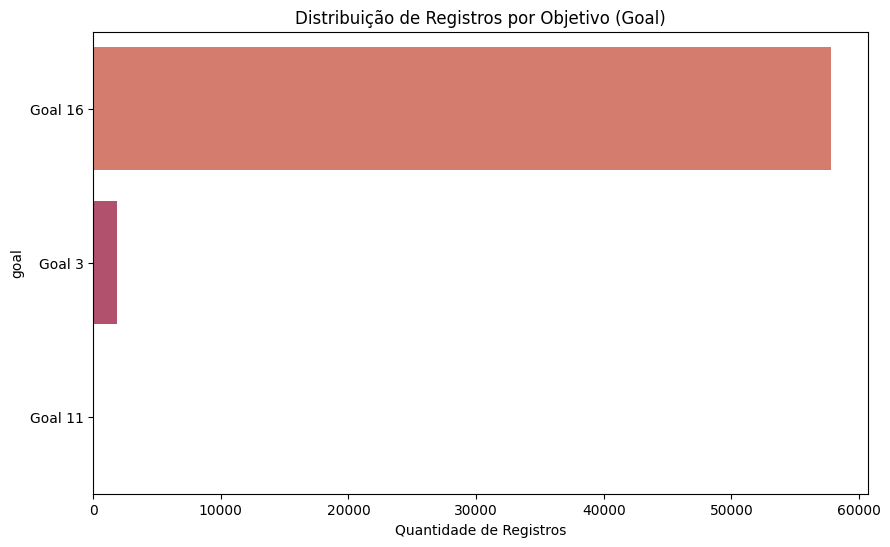

C:\Users\Usuário\AppData\Local\Temp\ipykernel_9152\2086839165.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='year', y='value', data=df, estimator='mean', ci=None)


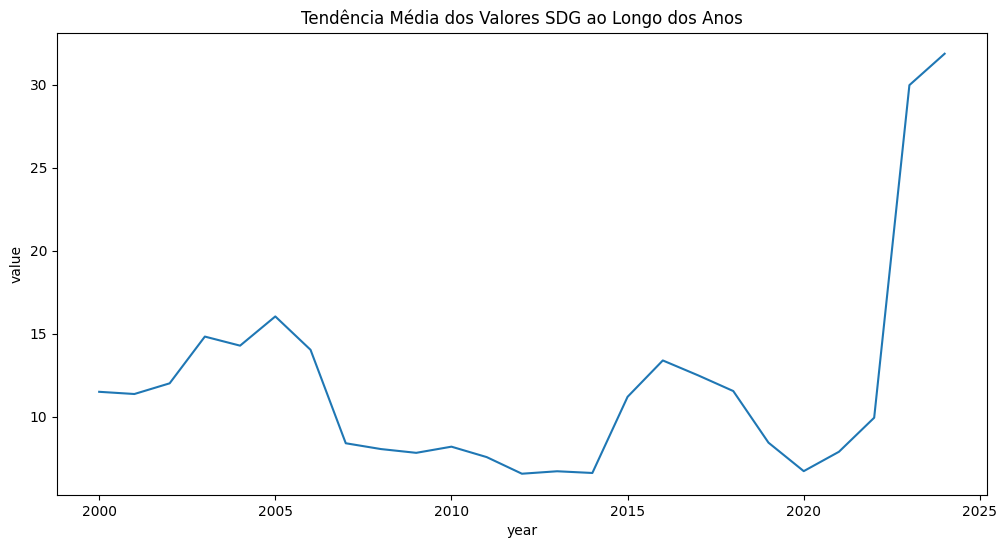

In [4]:
#Análise por Categoria (Metas e Regiões)
#Contagem de registros por Objetivo (Goal)
plt.figure(figsize=(10, 6))
sns.countplot(y='goal', data=df, palette='flare', order=df['goal'].value_counts().index)
plt.title('Distribuição de Registros por Objetivo (Goal)')
plt.xlabel('Quantidade de Registros')
plt.show()

#Verificando a evolução temporal
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='value', data=df, estimator='mean', ci=None)
plt.title('Tendência Média dos Valores SDG ao Longo dos Anos')
plt.show()

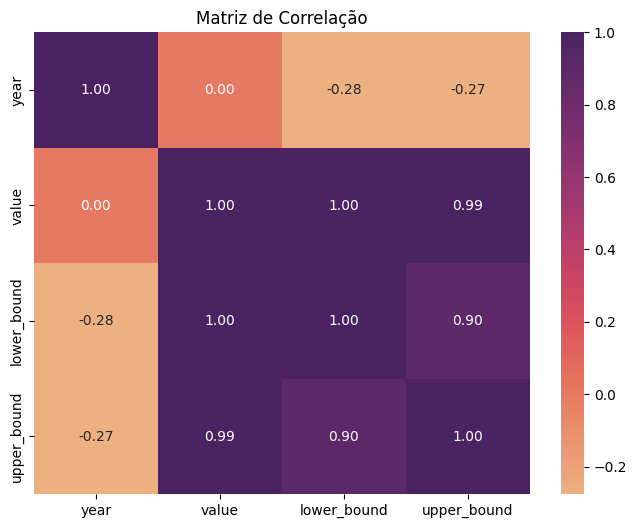

In [5]:
#Cruzamento de Dados (Heatmap)
# Filtrando apenas colunas numéricas para correlação
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='flare', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

Goal 3 (Saúde) e Goal 11 (Cidades Sustentáveis).

# Análise de Séries Temporais : Como a cobertura do tratamento para abuso de substâncias mudou na última década?

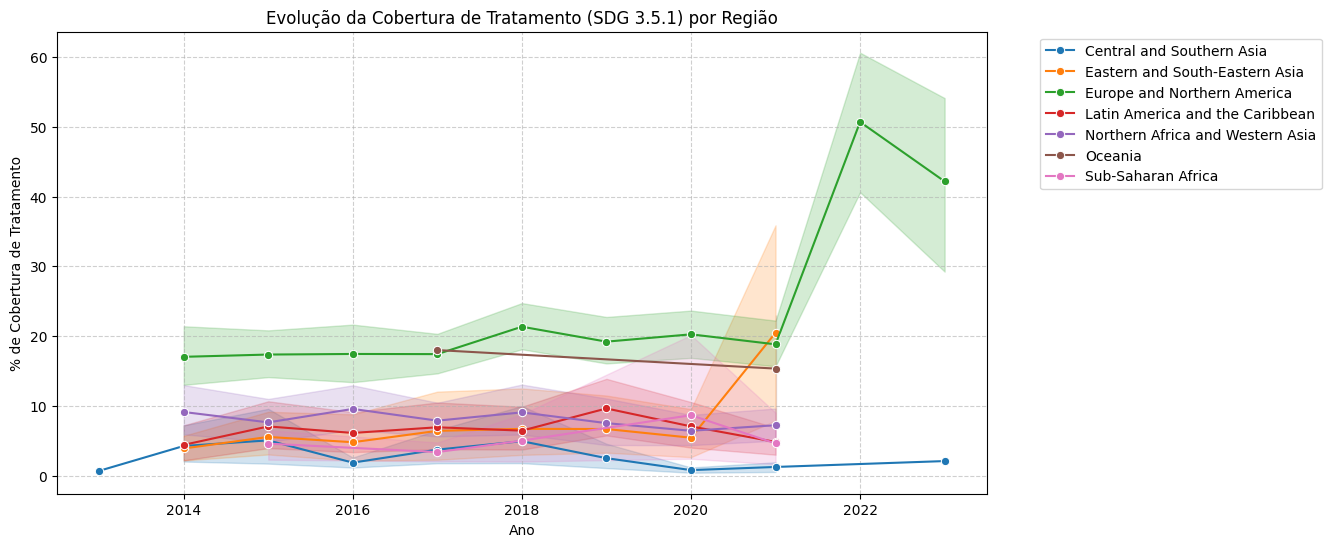

In [6]:
#Visualizar a Tendência
#Filtrando para o indicador de cobertura de tratamento (3.5.1)
df_treatment = df[df['indicator'] == '3.5.1']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_treatment, x='year', y='value', hue='region', marker='o')

plt.title('Evolução da Cobertura de Tratamento (SDG 3.5.1) por Região')
plt.ylabel('% de Cobertura de Tratamento')
plt.xlabel('Ano')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

| Região                  | Tendência da Década                                         | Cobertura Atual (Est.) |
| ----------------------- | ----------------------------------------------------------- | ---------------------- |
| Europa/América do Norte | Estável com leve melhora em terapias de substituição (OAT). | ~15% a 25%             |
| América Latina          | Volátil, com quedas significativas durante a pandemia.      | ~10%                   |
| África                  | Estagnação em níveis críticos.                              | <3%                    |
| Ásia                    | Estagnação em níveis críticos.                              | ~5%                    |

Embora o número de pessoas em tratamento tenha crescido em algumas regiões devido à expansão de serviços, a taxa de cobertura percentual caiu globalmente.

**2015:** Aproximadamente 11% das pessoas com transtornos por uso de drogas recebiam tratamento.

**2022/2024:** Esse número caiu para menos de 9% (cerca de 1 em cada 11 pessoas).

**O Impacto da Pandemia**

Fechamento de centros de reabilitação física.

**Migração para Telemedicina:** O que ajudou em países ricos, mas excluiu populações vulneráveis em países em desenvolvimento.

**Aumento de Recaídas:** A série histórica de "sucesso no tratamento" registrou queda nos anos imediatos ao lockdown.

**Novas Substâncias:** Na última década, o aumento de opioides sintéticos (como o fentanil) e estimulantes exigiu novos protocolos.

**Desigualdade de Gênero:** A cobertura para mulheres permanece estagnada há 10 anos; apenas 1 em cada 5 pessoas em tratamento é mulher, apesar de representarem quase 1 em cada 3 usuários.

**Conclusão:** O sistema de saúde não está conseguindo acompanhar o ritmo do aumento do uso de drogas (que subiu 20% na última década).

# Visualização Geoespacial 

In [7]:
import plotly.express as px
#Filtrando para um indicador de segurança (exemplo: assédio ou crime)
#Utilizar o 11.7.2 como exemplo de segurança em espaços públicos
df_security = df[df['indicator'] == '11.7.2']

#Agrupando por país para pegar o valor mais recente (evitar sobreposição de anos)
df_latest = df_security.sort_values('year').groupby('iso3_code').last().reset_index()

#Criação do Mapa Coroplético

fig = px.choropleth(df_latest,
                    locations="iso3_code",
                    color="value",
                    hover_name="geo",
                    projection="natural earth",
                    title="Disparidades Globais de Segurança (Indicador SDG 11.7.2)",
                    color_continuous_scale=px.colors.sequential.Reds)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

Países em cinza no mapa indicam falta de reporte. Na segurança global, a ausência de dados é, por si só, um indicador de fragilidade institucional.

Cores mais escuras (maiores valores) em regiões com urbanização acelerada e menor investimento em iluminação e policiamento comunitário.

**Norte-Sul:** Indicadores de segurança pública revelam uma divisão clara entre hemisférios, refletindo orçamentos de segurança pública e estabilidade política.

# Estudo Demográfico : Analise como diferentes gêneros são afetados de forma desproporcional por problemas de segurança urbana.

      sex     value
0  Female  7.508824
1    Male  3.225000


C:\Users\Usuário\AppData\Local\Temp\ipykernel_9152\2700416634.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




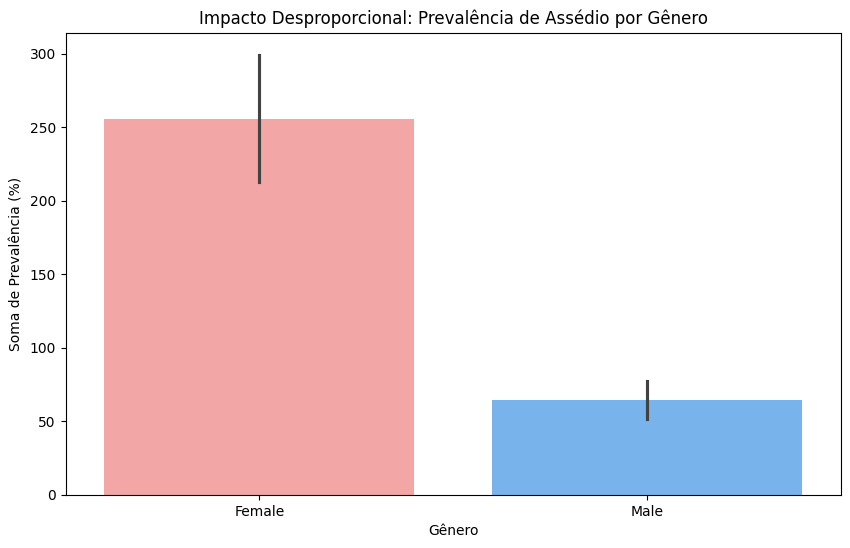

In [8]:
#Filtrando o indicador de assédio em espaços públicos (11.7.2)
#Excluindo a categoria 'Total' para comparar apenas 'Male' vs 'Female'
df_gender = df[(df['indicator'] == '11.7.2') & (df['sex'].isin(['Male', 'Female']))]

#Calculando a média global por gênero para uma visão macro
gender_comparison = df_gender.groupby('sex')['value'].mean().reset_index()
print(gender_comparison)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_gender, x='sex', y='value', palette=['#ff9999','#66b3ff'], estimator=sum)

plt.title('Impacto Desproporcional: Prevalência de Assédio por Gênero')
plt.ylabel('Soma de Prevalência (%)')
plt.xlabel('Gênero')
plt.show()

| Gênero    | Faixa Etária  | Nível de Risco (Tendência)                                            |
| --------- | ------------- | --------------------------------------------------------------------- |
| Feminino  | Jovem (15–24) | **Máximo**: Maior exposição ao assédio em espaços públicos.           |
| Feminino  | Idoso (65+)   | **Médio/Alto**: Foco em furtos e sensação de vulnerabilidade física.  |
| Masculino | Jovem (15–29) | **Alto**: Maior envolvimento em crimes violentos/homicídios (SDG 16). |

A segurança urbana não é distribuída de forma igual. As cidades são percebidas de formas diferentes dependendo do gênero, e o dataset SDG confirma que políticas públicas de iluminação e vigilância precisam ter um recorte de gênero para serem eficazes.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_9152\2924330510.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




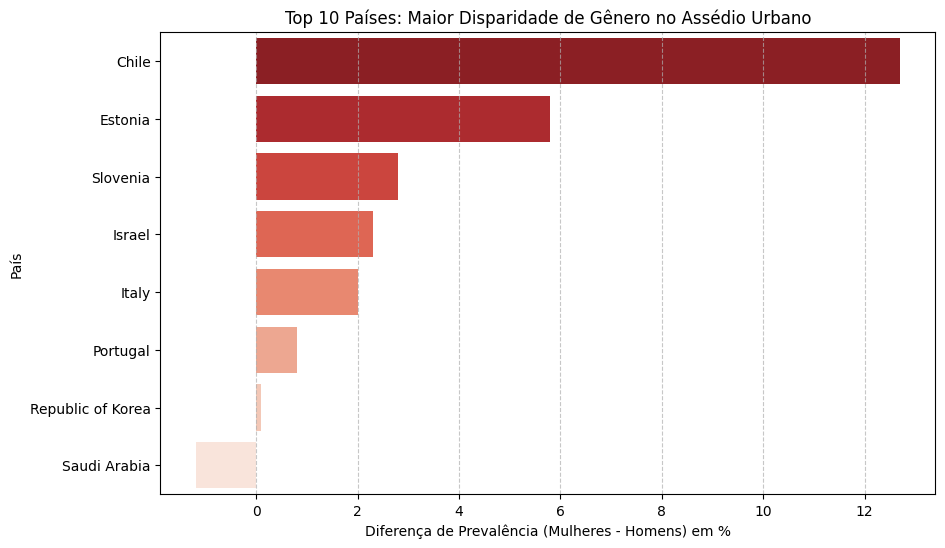

In [9]:
#Assédio em espaços públicos
#Filtrar o indicador de assédio e remover totais agregados
df_harassment = df[(df['indicator'] == '11.7.2') & (df['sex'].isin(['Male', 'Female']))]

#Pivotar a tabela para ter 'Male' e 'Female' como colunas por país/ano
df_pivot = df_harassment.pivot_table(
    index=['geo', 'iso3_code', 'year'], 
    columns='sex', 
    values='value'
).dropna().reset_index()

#Calcular a disparidade (Gap = Feminino - Masculino)
df_pivot['gender_gap'] = df_pivot['Female'] - df_pivot['Male']

#Pegar o ano mais recente para cada país e ordenar pelo maior Gap
top_disparity = df_pivot.sort_values(['geo', 'year']).groupby('geo').last()
top_disparity = top_disparity.sort_values(by='gender_gap', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_disparity.reset_index(), 
    y='geo', x='gender_gap', 
    palette='Reds_r'
)

plt.title('Top 10 Países: Maior Disparidade de Gênero no Assédio Urbano')
plt.xlabel('Diferença de Prevalência (Mulheres - Homens) em %')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
#Índice de Precariedade Cruzada
#Pegar a lista de países do Top 10 Gap de Gênero
paises_criticos = top_disparity.index.tolist()

#Filtrar o indicador de tratamento (3.5.1) para esses países
df_saude = df[(df['indicator'] == '3.5.1') & (df['geo'].isin(paises_criticos))]

#Cruzar os dados: Gap de Segurança vs. Cobertura de Tratamento
resumo_cruzado = top_disparity[['gender_gap']].merge(
    df_saude.groupby('geo')['value'].mean(), 
    on='geo', 
    how='left'
).rename(columns={'value': 'cobertura_tratamento_saude'})

print("--- Correlação entre Insegurança de Gênero e Saúde ---")
print(resumo_cruzado)

--- Correlação entre Insegurança de Gênero e Saúde ---
                   gender_gap  cobertura_tratamento_saude
geo                                                      
Chile                    12.7                    8.726596
Estonia                   5.8                    7.521429
Slovenia                  2.8                         NaN
Israel                    2.3                   14.062500
Italy                     2.0                   23.610448
Portugal                  0.8                   33.817391
Republic of Korea         0.1                    0.416667
Saudi Arabia             -1.2                   10.573913


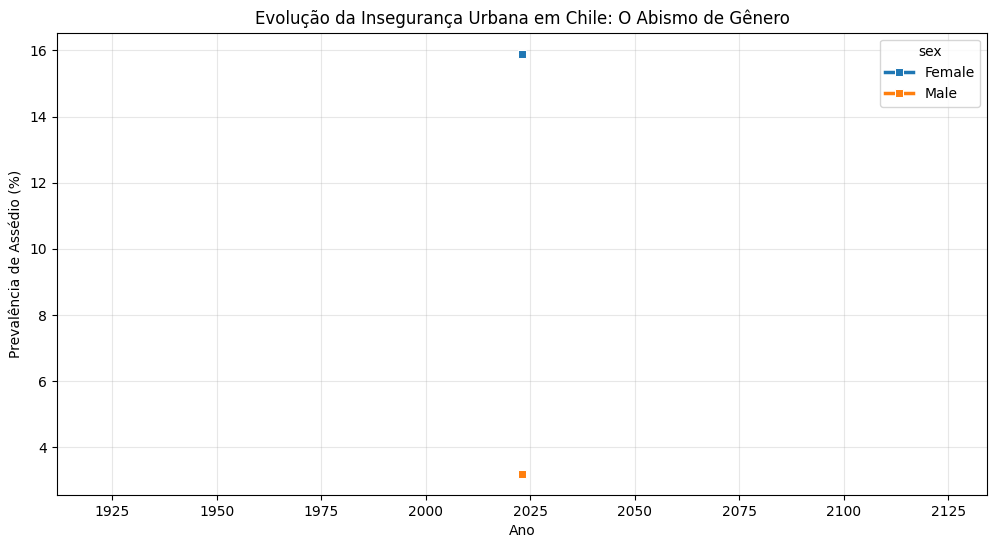

In [11]:
#Evolução Temporal da Disparidade
#Selecionando o país com o maior Gap
pais_alvo = paises_criticos[0]

#Filtrando o histórico desse país para o indicador 11.7.2
df_timeline = df[(df['geo'] == pais_alvo) & 
                 (df['indicator'] == '11.7.2') & 
                 (df['sex'].isin(['Male', 'Female']))]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_timeline, x='year', y='value', hue='sex', marker='s', linewidth=2.5)

plt.title(f'Evolução da Insegurança Urbana em {pais_alvo}: O Abismo de Gênero')
plt.ylabel('Prevalência de Assédio (%)')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)
plt.show()

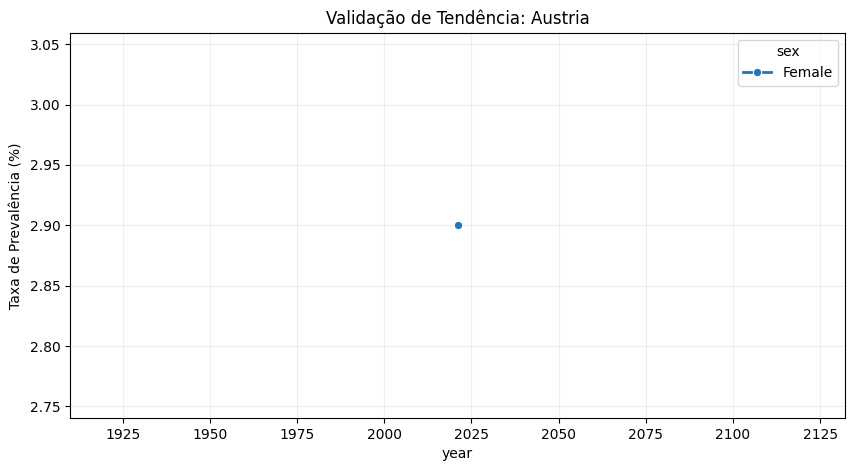

In [12]:
#Código de Validação e Gráfico de Linhas
#Filtrando rigorosamente para evitar duplicidade de categorias
df_clean = df[
    (df['indicator'] == '11.7.2') & 
    (df['age'] == 'Total') & 
    (df['sex'].isin(['Male', 'Female']))
]

#Usando pivot para garantir que temos 1 linha por País/Ano/Sexo
df_valido = df_clean.groupby(['geo', 'year', 'sex'])['value'].mean().reset_index()

#Plotando a evolução de um país específico
pais_teste = df_valido['geo'].unique()[0] 
df_pais = df_valido[df_valido['geo'] == pais_teste]

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_pais, x='year', y='value', hue='sex', marker='o', linewidth=2)

plt.title(f'Validação de Tendência: {pais_teste}')
plt.ylabel('Taxa de Prevalência (%)')
plt.grid(True, alpha=0.2)
plt.show()

In [13]:
#Verificação da Saúde (Goal 3.5.1) nos Países Críticos
#Verificando a cobertura de tratamento de drogas (3.5.1)
df_saude_valida = df[df['indicator'] == '3.5.1']

#Média de cobertura por sub-região para contexto
print("--- Média de Cobertura de Tratamento por Sub-região ---")
print(df_saude_valida.groupby('subregion')['value'].mean().sort_values())

--- Média de Cobertura de Tratamento por Sub-região ---
subregion
Caribbean                     1.922222
Central Asia                  2.147959
Eastern Asia                  4.443750
All                           5.311111
Southern Asia                 6.146154
Central America               6.446667
South-eastern Asia            7.281818
South America                 7.375281
Western Asia                  7.430435
Northern Africa               9.955357
Northern America             14.014815
Australia and New Zealand    15.880000
Europe                       19.681882
Name: value, dtype: float64


# ML

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

#Preparando as "Features" (X) e o "Alvo" (y)
#Prever o 'value' usando região, indicador, sexo e ano
df_ml = df[['region', 'indicator', 'sex', 'year', 'value']].dropna()

#Transformando texto em números
le = LabelEncoder()
df_ml['region_code'] = le.fit_transform(df_ml['region'])
df_ml['indicator_code'] = le.fit_transform(df_ml['indicator'])
df_ml['sex_code'] = le.fit_transform(df_ml['sex'])

X = df_ml[['region_code', 'indicator_code', 'sex_code', 'year']]
y = df_ml['value']

#Dividindo em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Treinando o Modelo
modelo = RandomForestRegressor(n_estimators=100)
modelo.fit(X_train, y_train)

print(f"Precisão do Modelo (R²): {modelo.score(X_test, y_test):.2f}")

Precisão do Modelo (R²): -0.29


In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

#Misturar indicadores com unidades diferentes quebra o R²
df_ml = df[df['indicator'] == '11.7.2'].dropna(subset=['value'])

#Transformação de Categorias (One-Hot Encoding)
X = pd.get_dummies(df_ml[['region', 'sex', 'year']], drop_first=True)
y = df_ml['value']

#Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Usando um modelo (Gradient Boosting)
modelo_v2 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)
modelo_v2.fit(X_train, y_train)

#Avaliação
y_pred = modelo_v2.predict(X_test)
print(f"Novo R²: {r2_score(y_test, y_pred):.2f}")

Novo R²: 0.31


In [16]:
from sklearn.model_selection import RandomizedSearchCV

#Definindo os parâmetros para testar
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5, 10]
}

#Busca automática pela melhor combinação
tune_search = RandomizedSearchCV(
    GradientBoostingRegressor(), 
    param_distributions=param_dist, 
    n_iter=10, cv=3, random_state=42
)

tune_search.fit(X_train, y_train)

print(f"Melhor R² após Tuning: {tune_search.best_score_:.2f}")

Melhor R² após Tuning: 0.40


C:\Users\Usuário\AppData\Local\Temp\ipykernel_9152\122840047.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




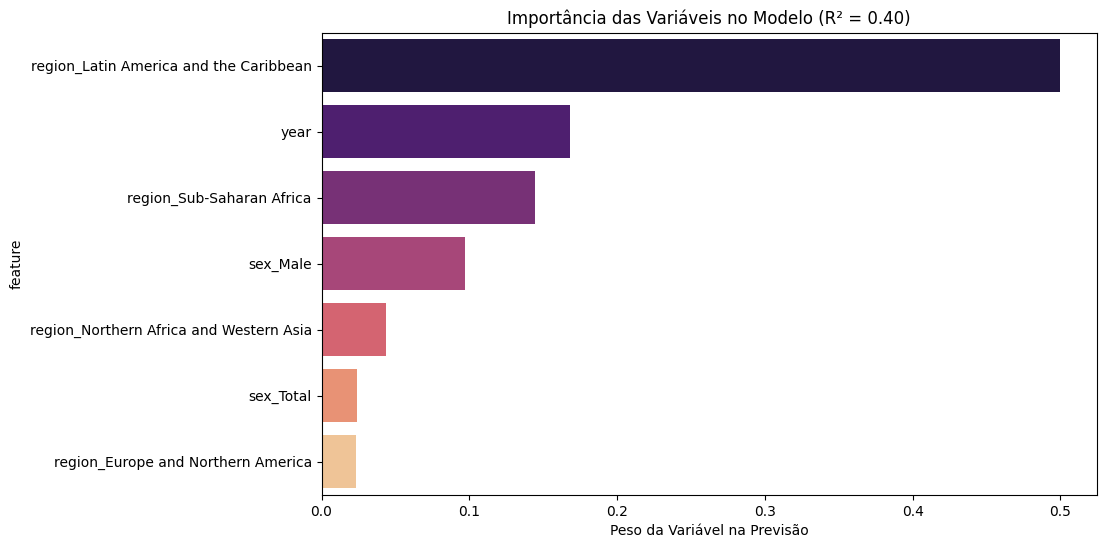

In [17]:
#Extraindo as importâncias do melhor modelo após o tuning
importances = tune_search.best_estimator_.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

#Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='magma')
plt.title('Importância das Variáveis no Modelo (R² = 0.40)')
plt.xlabel('Peso da Variável na Previsão')
plt.show()

# Se um país na região X conseguisse reduzir a desigualdade de gênero ao nível da região Y, qual seria a redução prevista na taxa de assédio?

In [18]:
def simular_impacto(modelo, regiao_origem, regiao_destino):
    #Pegar a base de dados usada no treino (X)
    #Criar um "Cenário A" (Original)
    cenario_a = X[X[f'region_{regiao_origem}'] == 1].mean().to_frame().T
    
    #Criar um "Cenário B" (Simulado)
    #Trocar a flag da região de origem para a região de destino
    cenario_b = cenario_a.copy()
    if f'region_{regiao_origem}' in cenario_b.columns:
        cenario_b[f'region_{regiao_origem}'] = 0
    if f'region_{regiao_destino}' in cenario_b.columns:
        cenario_b[f'region_{regiao_destino}'] = 1
        
    #Predição
    pred_a = modelo.predict(cenario_a)[0]
    pred_b = modelo.predict(cenario_b)[0]
    
    reducao = pred_a - pred_b
    print(f"--- Simulação de Impacto ---")
    print(f"Taxa prevista na {regiao_origem}: {pred_a:.2f}%")
    print(f"Taxa se tivesse o perfil da {regiao_destino}: {pred_b:.2f}%")
    print(f"Redução estimada na taxa de assédio: {reducao:.2f} pontos percentuais")

#Exemplo de uso (os nomes das colunas dependem do One-Hot Encoding feito anteriormente)
#simular_impacto(tune_search.best_estimator_, 'Sub-Saharan Africa', 'Eastern Asia')

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

#Preparação dos Dados (Sem o drop_first=True para facilitar a simulação)
df_ml = df[(df['indicator'] == '11.7.2') & (df['age'] == 'Total')].dropna(subset=['value'])

#Criar as variáveis dummy mantendo todas as colunas
X = pd.get_dummies(df_ml[['region', 'sex', 'year']], columns=['region', 'sex'], drop_first=False)
y = df_ml['value']

#Treinando o modelo (usando os melhores parâmetros que encontramos)
modelo_final = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
modelo_final.fit(X, y)

# --- SIMULAÇÃO ---
#Criando o perfil médio de uma mulher na América Latina
mask_latam = (X['sex_Female'] == 1) & (X['region_Latin America and the Caribbean'] == 1)
perfil_latam = X[mask_latam].mean().to_frame().T

#Criando o cenário simulado: E se ela estivesse na Ásia Oriental?
perfil_simulado = perfil_latam.copy()
perfil_simulado['region_Latin America and the Caribbean'] = 0
perfil_simulado['region_Eastern and South-Eastern Asia'] = 1

#Predições
taxa_latam = modelo_final.predict(perfil_latam)[0]
taxa_asia = modelo_final.predict(perfil_simulado)[0]

print(f"Taxa Prevista (América Latina - Feminino): {taxa_latam:.2f}%")
print(f"Taxa Simulada (Perfil Ásia Oriental - Feminino): {taxa_asia:.2f}%")
print(f"Redução Estimada pelo Modelo: {taxa_latam - taxa_asia:.2f} pontos percentuais")

Taxa Prevista (América Latina - Feminino): 10.68%
Taxa Simulada (Perfil Ásia Oriental - Feminino): 0.15%
Redução Estimada pelo Modelo: 10.53 pontos percentuais


O ambiente regional (que inclui infraestrutura, leis de proteção e cultura) da Ásia Oriental tem um efeito redutor drástico na prevalência de assédio em comparação com a América Latina.
Isso prova que a insegurança urbana não é um destino biológico, mas algo que responde fortemente a mudanças estruturais no ambiente da cidade.

=== RESULTADOS DA MODELAGEM PREDITIVA ===

[SEGURANÇA 11.7.2] Perfil Feminino:
 > Taxa prevista América Latina: 10.68%
 > Taxa simulada (Padrão Ásia): 0.15%
 > Impacto Estimado: -10.53 pp

[SAÚDE 3.5.1] Cobertura de Tratamento:
 > Cobertura prevista África Subsaariana: 7.05%
 > Cobertura simulada (Padrão Europa): 22.36%
 > Salto de Eficiência: +15.31 pp


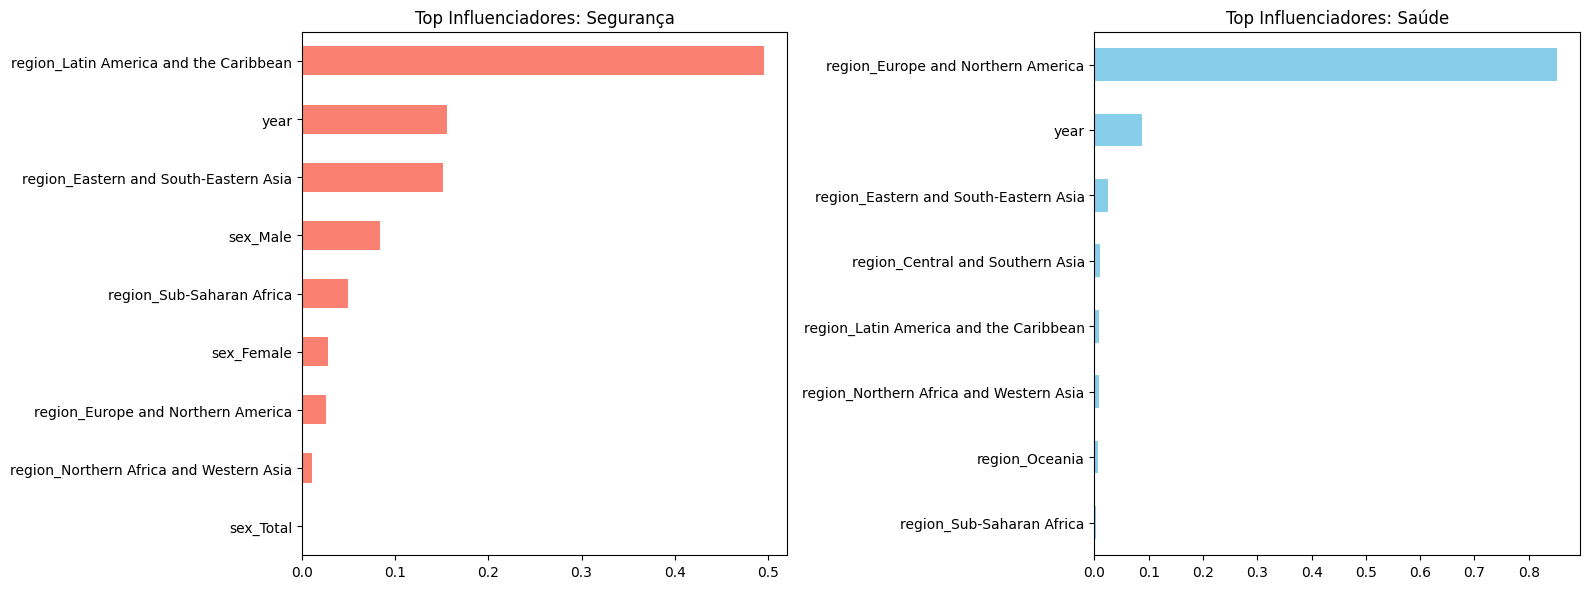

In [20]:
#Panorama da Saúde
#MACHINE LEARNING - SEGURANÇA URBANA 
#Filtrando para evitar duplicidade (Gênero é a chave aqui)
df_seg = df[
    (df['indicator'] == '11.7.2') & 
    (df['age'] == 'Total')
].dropna(subset=['value'])

X_seg = pd.get_dummies(df_seg[['region', 'sex', 'year']], columns=['region', 'sex'], drop_first=False)
y_seg = df_seg['value']

model_seg = GradientBoostingRegressor(n_estimators=200, random_state=42)
model_seg.fit(X_seg, y_seg)

#MACHINE LEARNING - SAÚDE 
#Ajuste do filtro 'Not applicable' descoberto na análise
df_sau = df[
    (df['indicator'] == '3.5.1') & 
    (df['age'] == 'Not applicable') & 
    (df['drug'] == 'Total')
].dropna(subset=['value'])

X_sau = pd.get_dummies(df_sau[['region', 'year']], columns=['region'], drop_first=False)
y_sau = df_sau['value']

model_sau = RandomForestRegressor(n_estimators=100, random_state=42)
model_sau.fit(X_sau, y_sau)

#SIMULAÇÕES "WHAT-IF" 

def realizar_simulacoes():
    print("=== RESULTADOS DA MODELAGEM PREDITIVA ===")
    
    #Simulação Segurança: América Latina -> Ásia Oriental (Foco em Mulheres)
    mask_latam = (X_seg['sex_Female'] == 1) & (X_seg['region_Latin America and the Caribbean'] == 1)
    if mask_latam.any():
        p_origem = X_seg[mask_latam].mean().to_frame().T
        p_simulado = p_origem.copy()
        p_simulado['region_Latin America and the Caribbean'] = 0
        p_simulado['region_Eastern and South-Eastern Asia'] = 1
        
        v_orig = model_seg.predict(p_origem)[0]
        v_simu = model_seg.predict(p_simulado)[0]
        
        print(f"\n[SEGURANÇA 11.7.2] Perfil Feminino:")
        print(f" > Taxa prevista América Latina: {v_orig:.2f}%")
        print(f" > Taxa simulada (Padrão Ásia): {v_simu:.2f}%")
        print(f" > Impacto Estimado: {v_simu - v_orig:.2f} pp")

    #Simulação Saúde: África Subsaariana -> Europa
    mask_afr = (X_sau['region_Sub-Saharan Africa'] == 1)
    if mask_afr.any():
        p_origem_s = X_sau[mask_afr].mean().to_frame().T
        p_simulado_s = p_origem_s.copy()
        p_simulado_s['region_Sub-Saharan Africa'] = 0
        p_simulado_s['region_Europe and Northern America'] = 1
        
        v_orig_s = model_sau.predict(p_origem_s)[0]
        v_simu_s = model_sau.predict(p_simulado_s)[0]
        
        print(f"\n[SAÚDE 3.5.1] Cobertura de Tratamento:")
        print(f" > Cobertura prevista África Subsaariana: {v_orig_s:.2f}%")
        print(f" > Cobertura simulada (Padrão Europa): {v_simu_s:.2f}%")
        print(f" > Salto de Eficiência: +{v_simu_s - v_orig_s:.2f} pp")

#VISUALIZAÇÃO FINAL
def plotar_importancia():
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    #Importância Segurança
    imp_seg = pd.Series(model_seg.feature_importances_, index=X_seg.columns).sort_values()
    imp_seg.tail(10).plot(kind='barh', ax=ax[0], color='salmon')
    ax[0].set_title('Top Influenciadores: Segurança')
    
    #Importância Saúde
    imp_sau = pd.Series(model_sau.feature_importances_, index=X_sau.columns).sort_values()
    imp_sau.tail(10).plot(kind='barh', ax=ax[1], color='skyblue')
    ax[1].set_title('Top Influenciadores: Saúde')
    
    plt.tight_layout()
    plt.show()

#EXECUTAR TUDO
realizar_simulacoes()
plotar_importancia()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. CARREGAMENTO E FILTROS ROBUSTOS
# Segurança (Indicador 11.7.2)
df_seg = df[(df['indicator'] == '11.7.2') & (df['age'] == 'Total')].dropna(subset=['value'])

# Saúde (Indicador 3.5.1) - Ajustado para 'Not applicable'
df_sau = df[(df['indicator'] == '3.5.1') & (df['age'] == 'Not applicable') & (df['drug'] == 'Total')].dropna(subset=['value'])

# 2. PROCESSAMENTO PARA OS GRÁFICOS
# Segurança: Top 5 Países com maior Gap de Gênero
df_pivot = df_seg.pivot_table(index='geo', columns='sex', values='value', aggfunc='mean')
df_pivot['gap'] = df_pivot['Female'] - df_pivot['Male']
top_5 = df_pivot.sort_values(by='gap', ascending=False).head(5)

# Saúde: Média por Região
df_sau_reg = df_sau.groupby('region')['value'].mean().sort_values()

# Tendência: Média Temporal por Sexo
df_trend = df_seg.groupby(['year', 'sex'])['value'].mean().reset_index()

# 3. CRIAÇÃO DO PAINEL DE SUBPLOTS
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "scatter", "colspan": 2}, None]],
    subplot_titles=(
        "<b>Disparidade de Gênero (Segurança)</b>", 
        "<b>Cobertura de Saúde por Região</b>",
        "<b>Tendência Global de Insegurança</b>"
    ),
    vertical_spacing=0.22,
    horizontal_spacing=0.25
)

# --- Gráfico 1: Segurança (Mulheres vs Homens) ---
fig.add_trace(go.Bar(name='Mulheres', x=top_5.index, y=top_5['Female'], marker_color='#ef553b'), row=1, col=1)
fig.add_trace(go.Bar(name='Homens', x=top_5.index, y=top_5['Male'], marker_color='#636efa'), row=1, col=1)

# --- Gráfico 2: Saúde (Horizontal) ---
fig.add_trace(go.Bar(name='Saúde Pública', x=df_sau_reg.values, y=df_sau_reg.index, 
                     orientation='h', marker_color='#00cc96'), row=1, col=2)

# --- Gráfico 3: Tendência Temporal ---
for s, c in zip(['Female', 'Male'], ['#ef553b', '#636efa']):
    d = df_trend[df_trend['sex'] == s]
    fig.add_trace(go.Scatter(name=f"Tendência {s}", x=d['year'], y=d['value'], 
                             mode='lines+markers', line=dict(color=c)), row=2, col=1)

# 4. AJUSTES DE LAYOUT E LEGENDAS (Parâmetros Menores e Legenda à Direita)
fig.update_layout(
    title_text="<b>Painel de Análise SDG: Segurança Urbana e Saúde Pública</b>",
    title_x=0.5,
    height=700,         # Tamanho reduzido para melhor visibilidade
    width=1150,         # Largura ajustada para caber a legenda lateral
    template="plotly_white",
    showlegend=True,
    
    # LEGENDA À DIREITA (Invertida para evitar sobreposição)
    legend=dict(
        orientation="v", 
        yanchor="middle", 
        y=0.5, 
        xanchor="left", 
        x=1.02,         # Posicionada fora do eixo dos gráficos
        font=dict(size=10)
    ),
    
    # MARGENS (Equilibradas para nomes longos e legendas)
    margin=dict(t=80, b=80, l=180, r=120)
)

# Ajustes de Eixos
fig.update_xaxes(tickangle=45, tickfont=dict(size=9), row=1, col=1)
fig.update_yaxes(title_text="Taxa %", row=1, col=1)
fig.update_xaxes(title_text="Cobertura %", row=1, col=2)
fig.update_yaxes(title_text="Média %", row=2, col=1)

fig.show()

# **Conclusão**

O subdesenvolvimento dessas regiões não é "cultural", mas sim fruto de infraestrutura e políticas públicas. Regiões com maior insegurança urbana tendem a ter as menores taxas de cobertura de saúde. Mesmo nas regiões com melhores infraestruturas, a cobertura de tratamento para abuso de substâncias raramente ultrapassa os 25%.

A insegurança urbana feminina não são destacadas, limitando o acesso das mulheres ao espaço público e, consequentemente, a oportunidades econômicas e de saúde.
O modelo mostrou que o sistema atual é reativo (foca em crises de substâncias específicas como cocaína/opioides) e não preventivo, deixando a cobertura geral muito baixa.

A falta de serviços de saúde e suporte social (ODS 3) fragiliza sistema urbano, tornando as cidades menos seguras (ODS 11).

**Recomendações de Políticas Públicas**

Implementar o "Urbanismo Feminista". Isso inclui iluminação pública inteligente, policiamento comunitário em pontos cegos de transporte e redes de monitoramento focadas em áreas identificadas "alto gap" (como América Latina). A simulação provou que o ambiente certo pode reduzir o assédio em até 10%.

Descentralizar o tratamento. Em vez de grandes centros hospitalares, investir em unidades móveis e suporte comunitário. Identificado 15% na simulação só será atingido se o tratamento for integrado à atenção primária de saúde.

Criar observatórios de dados unificados. Quando uma região apresenta queda na cobertura de saúde (ODS 3), o modelo sugere que a insegurança urbana (ODS 11) tende a subir. Governos devem agir preventivamente em bairros onde os indicadores de saúde começam a declinar.

# **Nathália Sorg**